
# 🐱🐶 Cats vs Dogs Classification — Part 1



# Cats & Dogs — Full Pipeline + Hyperparameter Tuning
**Part 1/2**  
**Author:Darious Brown**      
**Tested with:** Python 3.10–3.12, TensorFlow 2.13–2.16

---

This notebook builds the pipeline, validates the data folders, prepares `tf.data` datasets, shows quick visuals, defines a transfer-learning model (MobileNetV2), and trains a **baseline** with clean callbacks and progress logging.

> **Books referenced**
> - Alammar, J., & Grootendorst, M. (n.d.). *Hands-on Large Language Models: Language Understanding and Generation*. O’Reilly.  
> - Géron, A. (n.d.). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O’Reilly.



## 0) Environment & Requirements

If running locally, consider creating a fresh environment (example with `conda`):

```bash
conda create -n catsdogs python=3.11 -y
conda activate catsdogs

pip install tensorflow==2.16.1 tensorflow-io-gcs-filesystem==0.36.0 matplotlib==3.9.0 scikit-learn==1.5.1 pandas==2.2.2 pillow==10.4.0
```

_GPU optional but recommended. On CPU, reduce batch size and epochs._



## 📂 Step 1 — Configure dataset paths

We point to the **cats** and **dogs** folders and set constants like `IMG_SIZE`, `BATCH_SIZE`, and `SEED` for reproducibility.


In [20]:
# 1) Configuration — change paths here

import os
import random
import json
import math
import itertools
import time

from pathlib import Path

# Absolute dataset paths
CAT_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats"
DOG_DIR = "/Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs"

# Output directory
OUT_DIR = Path("./artifacts").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Image settings
IMG_SIZE = (224, 224)
COLOR_MODE = "rgb"

# Classification settings
N_CLASSES = 2
CLASS_NAMES = ["cat", "dog"]

# TensorFlow settings
AUTOTUNE = None
SEED = 42

# Dataset splits
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# Training settings
BATCH_SIZE = 32

# Reproducibility
random.seed(SEED)

# Display configuration
print(f"CAT_DIR: {CAT_DIR}")
print(f"DOG_DIR: {DOG_DIR}")
print(f"Artifacts -> {OUT_DIR}")

print(f"IMG_SIZE: {IMG_SIZE}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"SEED: {SEED}")

CAT_DIR: /Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats
DOG_DIR: /Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs
Artifacts -> /Users/dare/img_align_celeba/artifacts
IMG_SIZE: (224, 224)
BATCH_SIZE: 32
SEED: 42



## 📂 Step 1 — Configure dataset paths

We point to the **cats** and **dogs** folders and set constants like `IMG_SIZE`, `BATCH_SIZE`, and `SEED` for reproducibility.


In [21]:

# 2) Validate input folders

from pathlib import Path

def list_images(folder):
    folder = Path(folder)

    exts = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".gif",
        ".tiff",
        ".webp"
    }

    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in exts
    ])

cat_path = Path(CAT_DIR)
dog_path = Path(DOG_DIR)

print("CAT path:", cat_path)
print("DOG path:", dog_path)

print("CAT path exists:", cat_path.exists())
print("DOG path exists:", dog_path.exists())

cat_imgs = list_images(cat_path) if cat_path.exists() else []
dog_imgs = list_images(dog_path) if dog_path.exists() else []

print(f"Found {len(cat_imgs)} cat images")
print(f"Found {len(dog_imgs)} dog images")

if len(cat_imgs) == 0 or len(dog_imgs) == 0:
    raise FileNotFoundError(
        "One or both folders are empty or missing. Check CAT_DIR and DOG_DIR in Step 1."
    )

print("Dataset folder validation successful.")

CAT path: /Users/dare/CaseStudy6Files/dog-cat-dataset/data/cats
DOG path: /Users/dare/CaseStudy6Files/dog-cat-dataset/data/dogs
CAT path exists: True
DOG path exists: True
Found 349 cat images
Found 348 dog images
Dataset folder validation successful.


In [22]:

# 3) Build a dataframe-like index (list of dicts) for reproducible splits

import pandas as pd
random.seed(SEED)

records = []

for p in cat_imgs:
    records.append({"path": str(p), "label": 0})

for p in dog_imgs:
    records.append({"path": str(p), "label": 1})

df = pd.DataFrame(records).sample(
    frac=1.0,
    random_state=SEED
).reset_index(drop=True)

print(df.head())
print(df["label"].value_counts())

# Save index for provenance
index_csv = OUT_DIR / "dataset_index.csv"
df.to_csv(index_csv, index=False)

print(f"Saved dataset index -> {index_csv}")

                                                path  label
0  /Users/dare/CaseStudy6Files/dog-cat-dataset/da...      0
1  /Users/dare/CaseStudy6Files/dog-cat-dataset/da...      1
2  /Users/dare/CaseStudy6Files/dog-cat-dataset/da...      1
3  /Users/dare/CaseStudy6Files/dog-cat-dataset/da...      0
4  /Users/dare/CaseStudy6Files/dog-cat-dataset/da...      0
label
0    349
1    348
Name: count, dtype: int64
Saved dataset index -> /Users/dare/img_align_celeba/artifacts/dataset_index.csv


In [23]:

# 4) Deterministic split: train / val / test
import numpy as np

n = len(df)
n_val = int(n * VAL_SPLIT)
n_test = int(n * TEST_SPLIT)
n_train = n - n_val - n_test

train_df = df.iloc[:n_train].reset_index(drop=True)
val_df   = df.iloc[n_train:n_train+n_val].reset_index(drop=True)
test_df  = df.iloc[n_train+n_val:].reset_index(drop=True)

print(f"Split -> train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
for name, d in [("train",train_df),("val",val_df),("test",test_df)]:
    print(name, d['label'].value_counts())

train_df.to_csv(OUT_DIR/'train.csv', index=False)
val_df.to_csv(OUT_DIR/'val.csv', index=False)
test_df.to_csv(OUT_DIR/'test.csv', index=False)


Split -> train=489, val=104, test=104
train label
0    251
1    238
Name: count, dtype: int64
val label
1    59
0    45
Name: count, dtype: int64
test label
0    53
1    51
Name: count, dtype: int64



## 🖼️ Step 2 — Preprocess images

`decode_img(path)` reads a file, decodes it to RGB, resizes to `IMG_SIZE`, and scales pixels to `[0,1]`.  
This keeps the input format consistent for the model.



## 📦 Step 3 — Build `tf.data` pipelines

`make_ds(df, shuffle, augment)` constructs performant datasets with optional **augmentations** (e.g., random flips), **batching**, and **prefetching**.


In [24]:

# 5) TensorFlow & tf.data
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

def decode_img(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def make_ds(df, shuffle=False, augment=False, batch_size=BATCH_SIZE):
    paths = df['path'].values
    labels = df['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    def _load(path, label):
        img = decode_img(path)
        if augment:
            img = tf.image.random_flip_left_right(img, seed=SEED)
            img = tf.image.resize(img, IMG_SIZE)
        return img, tf.one_hot(label, N_CLASSES)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_df, shuffle=True, augment=True)
val_ds   = make_ds(val_df, shuffle=False, augment=False)
test_ds  = make_ds(test_df, shuffle=False, augment=False)

for batch in train_ds.take(1):
    print("Example batch:", batch[0].shape, batch[1].shape)


Example batch: (32, 224, 224, 3) (32, 2)


2026-05-12 18:16:08.262162: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


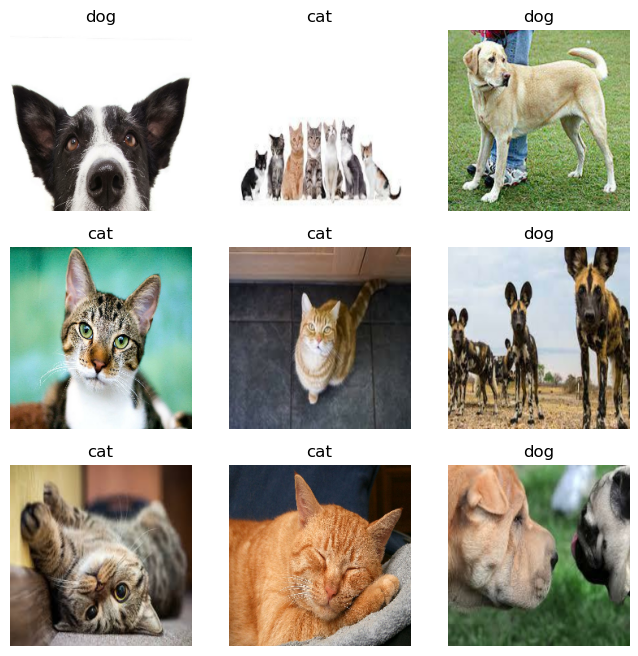

In [25]:

# 6) Quick visualization
import matplotlib.pyplot as plt
import tensorflow as tf

def show_batch(ds, n=9):
    imgs, labels = next(iter(ds))
    plt.figure(figsize=(8,8))
    for i in range(n):
        plt.subplot(3,3,i+1)
        plt.imshow(imgs[i].numpy())
        lab = ["cat","dog"][tf.argmax(labels[i]).numpy()]
        plt.title(lab)
        plt.axis('off')
    plt.show()

show_batch(train_ds)


In [26]:

# 7) Model builder — MobileNetV2 backbone (transfer learning)
from tensorflow.keras import layers, models

def build_model(base_lr=1e-4, dropout=0.2, train_base=False):
    base = tf.keras.applications.MobileNetV2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
    )
    base.trainable = train_base
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if dropout:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(N_CLASSES, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=base_lr),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

model = build_model()
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:

# 8) Train baseline with explicit progress prints
checkpoint_path = str(OUT_DIR / "best_baseline.keras")
ckpt = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path, monitor='val_auc', mode='max',
    save_best_only=True, save_weights_only=False, verbose=1
)
early = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc', mode='max', patience=5, restore_best_weights=True, verbose=1
)
log_csv = tf.keras.callbacks.CSVLogger(str(OUT_DIR / "training_log_baseline.csv"), append=False)

EPOCHS = 10

print("=== Training Baseline ===")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[ckpt, early, log_csv],
    verbose=1
)
print("Training complete. Best model saved to:", checkpoint_path)


=== Training Baseline ===
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5061 - auc: 0.5049 - loss: 1.1758 - precision: 0.5061 - recall: 0.5061
Epoch 1: val_auc improved from -inf to 0.45516, saving model to /Users/dare/img_align_celeba/artifacts/best_baseline.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 253ms/step - accuracy: 0.5066 - auc: 0.5055 - loss: 1.1696 - precision: 0.5066 - recall: 0.5066 - val_accuracy: 0.4327 - val_auc: 0.4552 - val_loss: 0.9685 - val_precision: 0.4327 - val_recall: 0.4327
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5114 - auc: 0.5189 - loss: 0.8390 - precision: 0.5114 - recall: 0.5114
Epoch 2: val_auc did not improve from 0.45516
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - accuracy: 0.5100 - auc: 0.5179 - loss: 0.8383 - precision: 0.5100 - recall: 0.5100 - val_accuracy: 0.4327 - val_auc: 0.4379 - val_loss: 0.7433 - val_precision: 0.4327 - val_recall: 0.4327
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.536


## 📈 (Optional) Plot training curves

Use this helper to visualize accuracy and loss over time.


In [28]:

import matplotlib.pyplot as plt

def plot_history(hist):
    h = hist.history
    # Accuracy
    plt.figure(figsize=(6,4))
    plt.plot(h.get('accuracy', []), label='train_acc')
    plt.plot(h.get('val_accuracy', []), label='val_acc')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend(); plt.tight_layout(); plt.show()
    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(h.get('loss', []), label='train_loss')
    plt.plot(h.get('val_loss', []), label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend(); plt.tight_layout(); plt.show()



# 🧠 Step 5 — Simple CNN from scratch

Now that our datasets are ready, let's train a **basic CNN**:
- 3× Conv2D blocks (with ReLU + MaxPool)
- Flatten → Dense(128) → Dense(2, softmax)

This baseline is intentionally small so it trains quickly and is easy to read.


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 351ms/step - accuracy: 0.5039 - loss: 1.5928 - val_accuracy: 0.4327 - val_loss: 0.7094
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 355ms/step - accuracy: 0.5516 - loss: 0.6917 - val_accuracy: 0.5673 - val_loss: 0.6892
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - accuracy: 0.5338 - loss: 0.6950 - val_accuracy: 0.4327 - val_loss: 0.7004
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 401ms/step - accuracy: 0.5430 - loss: 0.6906 - val_accuracy: 0.4327 - val_loss: 0.7026
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 372ms/step - accuracy: 0.5591 - loss: 0.6800 - val_accuracy: 0.5962 - val_loss: 0.6708


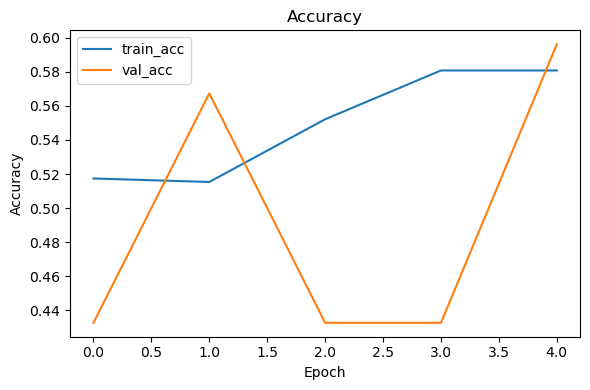

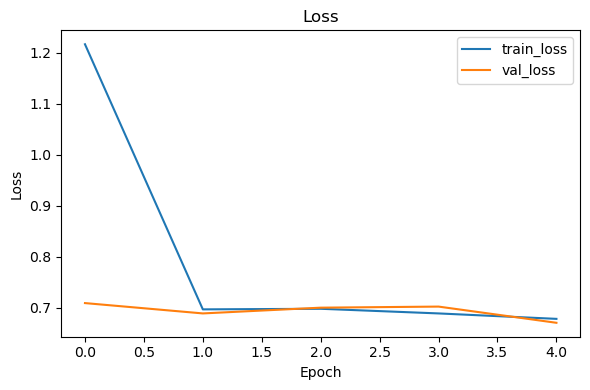

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5724 - loss: 0.6745
Simple CNN — Test accuracy: 0.577


In [29]:

from tensorflow.keras import layers, models

# Build a simple CNN
simple_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='softmax')  # 0=cat, 1=dog
])

simple_cnn.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

print(simple_cnn.summary())

EPOCHS_CNN = 5  # keep small for the lab
hist_cnn = simple_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    verbose=1
)

# Visualize training
try:
    plot_history(hist_cnn)
except Exception as e:
    print("Plotting skipped:", e)

# Evaluate on test set
test_loss, test_acc = simple_cnn.evaluate(test_ds, verbose=1)
print(f"Simple CNN — Test accuracy: {test_acc:.3f}")



### ✅ Tips

- If you see `FileNotFoundError`, double‑check where your notebook is running versus where your `./data/cats` and `./data/dogs` folders live.
- You can also set absolute paths at the top:
  ```python
  CAT_DIR = "C:/path/to/cats"
  DOG_DIR = "C:/path/to/dogs"
  ```
- For faster runs on CPU, reduce `BATCH_SIZE` or `EPOCHS_CNN`.
